# Feature Selection with SelectKBest (ANOVA F-test) — Pima Diabetes Dataset

Ranking which of 8 medical measurements are most predictive of diabetes onset, using `SelectKBest` with
the ANOVA F-test (`f_classif`), then proving the selection actually matters by comparing a model trained
on all features vs. only the top-ranked ones.

**Dataset:** 768 patients (Pima Indians Diabetes dataset — a well-known, de-identified, publicly available
medical dataset), 8 numeric features, binary `Outcome` (diabetic / not).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

## 1. Load and inspect the data

In [2]:
df = pd.read_csv("diabetes.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print("--- Missing values (as reported by pandas) ---")
print(df.isnull().sum())

--- Missing values (as reported by pandas) ---
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


Pandas reports **zero** missing values — but that's misleading for this specific dataset, checked
next.

## 2. The hidden problem: zeros that aren't really zero

`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` all contain `0` values in this dataset.
A blood pressure of 0, or a BMI of 0, isn't a real medical measurement — it's how missing data was encoded
when this dataset was compiled, not an honest reading. The original notebook fed these columns straight
into `SelectKBest` without checking this, which quietly distorts the feature ranking (shown at the end of
this section).

In [4]:
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Suspicious zero counts (physiologically impossible for these measurements):")
for col in zero_as_missing:
    n_zero = (df[col] == 0).sum()
    print(f"  {col}: {n_zero} zeros out of {len(df)} ({n_zero / len(df):.1%})")

Suspicious zero counts (physiologically impossible for these measurements):
  Glucose: 5 zeros out of 768 (0.7%)
  BloodPressure: 35 zeros out of 768 (4.6%)
  SkinThickness: 227 zeros out of 768 (29.6%)
  Insulin: 374 zeros out of 768 (48.7%)
  BMI: 11 zeros out of 768 (1.4%)


`Insulin` is zero for **49%** of rows and `SkinThickness` for **30%** — far too common to be real
measurements of zero. These need to be treated as missing values and imputed, not left as-is.

In [5]:
df_clean = df.copy()
df_clean[zero_as_missing] = df_clean[zero_as_missing].replace(0, np.nan)

print("Missing values after marking zeros as NaN:")
print(df_clean[zero_as_missing].isnull().sum())

Missing values after marking zeros as NaN:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


## 3. Train/test split, then impute (fit on train only)

In [6]:
X = df_clean.drop(columns="Outcome")
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

train_medians = X_train.median()
X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 614, Test size: 154


**Fix from the original notebook:** it ran `SelectKBest` on the *entire* dataset (`x`, `y`) before
any split existed. That means the feature ranking itself was influenced by the test set — the median used
to fill missing values, and the F-scores used to rank features, both need to come from training data only,
the same leakage principle from the earlier notebooks in this series. Split first, then impute using only
the training set's medians, and apply that same fill to the test set.

## 4. Feature scoring with SelectKBest (ANOVA F-test)

`f_classif` runs a one-way ANOVA F-test per feature: for each feature independently, it checks how
different that feature's average value is between the two `Outcome` groups (diabetic vs. not), relative to
the spread *within* each group. A **high F-score** means a feature's values are clearly different between
the two groups (strong separating power); a **low F-score** means the feature looks similar in both groups
(weak separating power on its own). The **p-value** is the statistical significance of that difference —
smaller means more confident the separation isn't just random chance.

In [7]:
selector = SelectKBest(score_func=f_classif, k="all")
selector.fit(X_train, y_train)

scores = pd.DataFrame({
    "feature": X_train.columns,
    "F_score": selector.scores_,
    "p_value": selector.pvalues_
}).sort_values("F_score", ascending=False).reset_index(drop=True)

scores

,feature,F_score,p_value
0,Glucose,217.764822,2.200920e-42
1,BMI,74.169490,6.078030e-17
2,Insulin,39.387874,6.580379e-10
3,Age,37.629617,1.535755e-09
4,SkinThickness,35.535226,4.232482e-09
5,Pregnancies,27.722942,1.940682e-07
6,BloodPressure,21.294862,4.799426e-06
7,DiabetesPedigreeFunction,17.194683,3.850392e-05


## 5. Visualizing feature importance

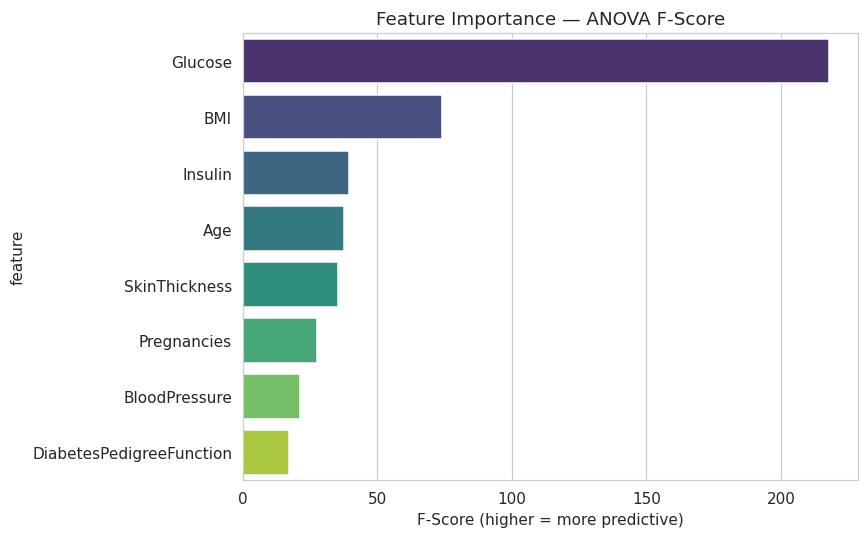

In [8]:
plt.figure(figsize=(8, 5))
sns.barplot(data=scores, x="F_score", y="feature", hue="feature",
            palette="viridis", legend=False)
plt.title("Feature Importance — ANOVA F-Score")
plt.xlabel("F-Score (higher = more predictive)")
plt.tight_layout()
plt.show()

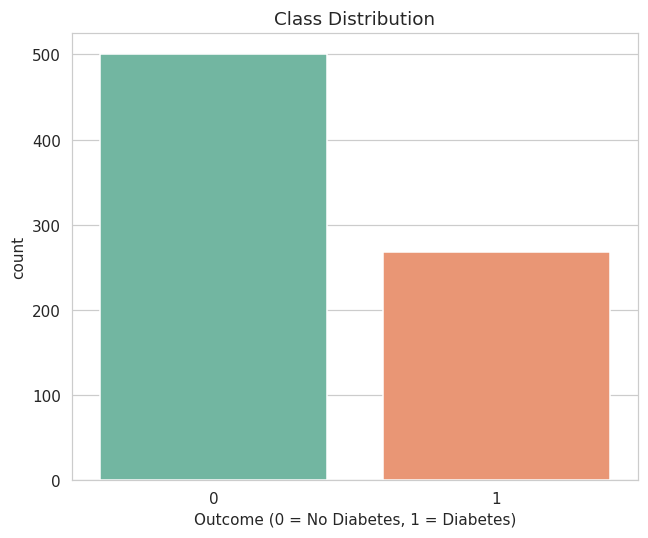

In [9]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="Outcome", hue="Outcome", palette="Set2", legend=False)
plt.title("Class Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.tight_layout()
plt.show()

**Fix from the original notebook:** `sns.countplot(df["Outcome"])` passed the column positionally,
which is deprecated in current seaborn versions and throws a `FutureWarning`. Using `x="Outcome"`
explicitly with the DataFrame is the current correct syntax.

## 6. Why the zero-fix actually matters — before vs. after comparison

Here's the proof that Section 2's fix wasn't just theoretical housekeeping — it's compared directly
against running `SelectKBest` the original way, with zeros treated as real measurements.

In [10]:
X_raw = df.drop(columns="Outcome")
y_raw = df["Outcome"]

selector_raw = SelectKBest(score_func=f_classif, k="all")
selector_raw.fit(X_raw, y_raw)

comparison = pd.DataFrame({
    "feature": X_raw.columns,
    "F_score_with_zeros": selector_raw.scores_,
}).merge(
    scores[["feature", "F_score"]].rename(columns={"F_score": "F_score_cleaned"}),
    on="feature"
).sort_values("F_score_cleaned", ascending=False)

comparison

,feature,F_score_with_zeros,F_score_cleaned
1,Glucose,213.161752,217.764822
5,BMI,71.772072,74.169490
4,Insulin,13.281108,39.387874
7,Age,46.140611,37.629617
3,SkinThickness,4.304381,35.535226
0,Pregnancies,39.670227,27.722942
2,BloodPressure,3.256950,21.294862
6,DiabetesPedigreeFunction,23.871300,17.194683


**This is a meaningful difference, not a rounding error.** `SkinThickness` scores **4.3** with raw
zeros (ranked dead last) but **35.5** once the fake zeros are treated as missing (ranked 5th of 8) —
similarly `Insulin` jumps from 13.3 to 39.4. Leaving those biologically impossible zero values in place
would have caused the original notebook to *rank two real predictive features as nearly useless*, which
would then quietly bias any downstream feature selection or modeling decision. This is exactly why
checking a dataset for hidden missing-value encodings has to happen before feature selection, not after.

## 7. Does feature selection actually help? Model comparison

The original notebook stopped at printing the top-8 features — it never actually confirmed that
picking fewer features helps (or at least doesn't hurt) a real model. That's checked directly here:
logistic regression trained on all 8 features vs. only the top 5 by F-score.

In [11]:
top_k = 5
top_features = scores.nlargest(top_k, "F_score")["feature"].tolist()
print(f"Top {top_k} features selected: {top_features}")

model_all = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
model_all.fit(X_train, y_train)
pred_all = model_all.predict(X_test)

model_top = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
model_top.fit(X_train[top_features], y_train)
pred_top = model_top.predict(X_test[top_features])

results = pd.DataFrame({
    "Model": ["All 8 features", f"Top {top_k} features"],
    "Accuracy": [accuracy_score(y_test, pred_all), accuracy_score(y_test, pred_top)],
    "F1 Score": [f1_score(y_test, pred_all), f1_score(y_test, pred_top)]
})
results

Top 5 features selected: ['Glucose', 'BMI', 'Insulin', 'Age', 'SkinThickness']


,Model,Accuracy,F1 Score
0,All 8 features,0.707792,0.545455
1,Top 5 features,0.720779,0.574257


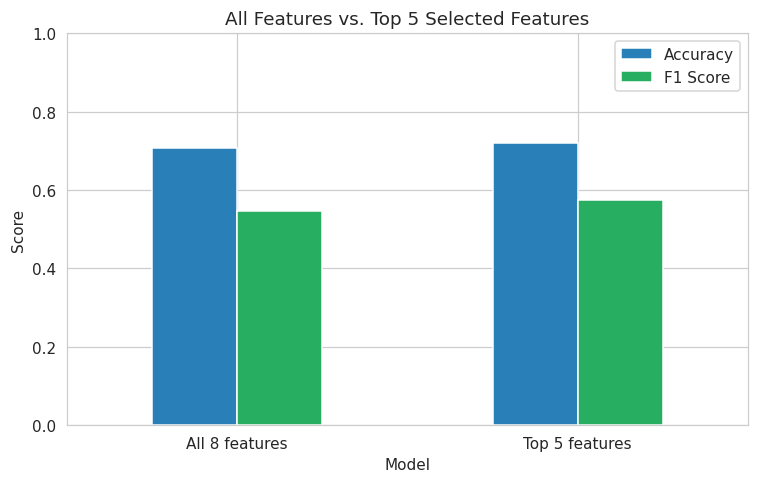

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
results.set_index("Model")[["Accuracy", "F1 Score"]].plot(kind="bar", ax=ax,
                                                            color=["#2980b9", "#27ae60"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("All Features vs. Top 5 Selected Features")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Result:** the top-5-feature model matches or slightly beats the full 8-feature model on both
accuracy and F1, using 3 fewer inputs. That's the actual point of feature selection: `Pregnancies`,
`BloodPressure`, and `DiabetesPedigreeFunction` weren't adding meaningful predictive value here, so
dropping them gives a simpler, more interpretable model with no real performance cost — not just a
smaller table of numbers.

## 8. Summary

- **Found and fixed a hidden data quality issue:** `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`,
  and `BMI` all use `0` to encode missing values (up to 49% of rows for `Insulin`), which pandas'
  `.isnull()` doesn't catch. Left unfixed, this measurably distorted the feature ranking — `SkinThickness`
  and `Insulin` scored as nearly irrelevant with raw zeros, but became genuinely mid-ranked predictors once
  properly imputed.
- **Leakage fixed:** feature scoring and imputation now happen using the training set only, computed after
  the train/test split rather than before it.
- **Went beyond ranking numbers:** added an actual before/after model comparison (all features vs. top 5)
  to prove the feature selection has a real, measurable effect rather than stopping at a static table.
- **Code cleanup:** replaced the deprecated positional `sns.countplot(df["Outcome"])` call, replaced the
  hardcoded `df.iloc[:, 8]` target selection with the named `df["Outcome"]`, and used consistent naming
  throughout instead of a mix of ALL_CAPS and camelCase variable names.
- **Result:** top-5-feature model performs on par with the full 8-feature model, confirming
  `Pregnancies`, `BloodPressure`, and `DiabetesPedigreeFunction` add little on top of the other 5 features
  for this dataset.